# DKT Post-Training Analysis

This notebook uses the trained DKT models from `DKT_training.ipynb` to extract pairwise topic interactions across the full dataset and build data-driven curriculum graphs for math and german.

**Stages.**
1. Data loading and preprocessing (identical pipeline to training)
2. Per-subject DKT inference and delta computation
3. Math topic-pair analysis
4. German topic-pair analysis
5. Cross-subject comparison
6. Prerequisite score
7. Curriculum graphs (topic level)
8. Skill-level curriculum graphs

In [19]:
from src.data import (
    load_all_data, get_latest_documents, build_topic_lookups, add_topic_depth,
    reparent_topics, prune_empty_topics, prune_empty_topics_translated,
    drop_topic_subtrees, summarize_transactions, split_by_subject,
)
from src.features import build_feature_matrix, prepare_seq
from src.models import create_model_lstm
from src.post_analysis import (
    predict_per_skill_probs,
    build_skill_info,
    build_pairwise_deltas,
    topic_topic_interactions_by_outcome, add_reverse_directionality,
    prerequisite_score,
    build_curriculum_graph, plot_curriculum_graph,
    skill_skill_interactions_by_outcome,
    build_skill_curriculum_graph, plot_skill_curriculum_html,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [20]:
# Configuration
from src.config import MASK_VALUE

SUBJECTS = ['math', 'german']

# Topic-tree surgery (consistent with DKT_training.ipynb).
TOPICS_TO_REPARENT = [2026, 2027, 2028]
REPARENT_UNDER     = 1
TOPICS_TO_DROP     = [2029, 3425]

# Model architecture (must match training: 256 LSTM units, no dropout).
params = {
    'batch_size'     : 32,
    'mask_value'     : MASK_VALUE,
    'recurrent_units': 256,
    'dropout_rate'   : 0.0,
    'optimizer'      : 'adam',
    'verbose'        : 0,
}

# Delta scaling mode for the topic-pair analysis:
#   'absolute' → raw |Δ P(correct)|
#   'relative' → |Δ| / (1 - p_current) for correct answers,
#                |Δ| /     p_current   for wrong answers.
# Headroom-normalized: a small absolute change near p≈1 (when correct) or
# near p≈0 (when wrong) is amplified, since the model had little room to move.
DELTA_MODE = 'absolute'

# When True, scale each source topic's correct/wrong mean by the share of
# attempts it received in that outcome class:
#   r_correct = n_correct / (n_correct + n_wrong)
#   r_wrong   = n_wrong   / (n_correct + n_wrong)
# This stops a tiny but high-magnitude wrong-answer pool from dominating the
# directionality signal on a topic that is nearly always answered correctly.
BALANCE_BY_OUTCOME_RATIO = False

# Tree relations between topics A and B (transitive — walk full ancestor chain).
RELATION_COLORS = {
    'ancestor→descendant': 'tab:blue',
    'descendant→ancestor': 'tab:orange',
    'sibling':             'tab:green',
    'other':               'tab:gray',
}

We use the trained DKT models (math and german) to extract pairwise topic interactions on the entire dataset. For each pair of topics (A, B), we compute |Δ P(correct on B)| around an answer to A, **split by whether A was answered correctly or wrongly**.

Two macro metrics drive the analysis:

- **`strength`** = (Δ_correct + Δ_wrong) / 2: overall intensity of the relation
- **`directionality`** in [-1, +1] = (Δ_correct - Δ_wrong) / `strength`
  - +1: answering A correctly drives B's probability, so **B is a prerequisite of A**
  - -1: answering A wrongly crashes B's probability, so **A is a prerequisite of B**
  - ~0: both directions equal, complementary or co-occurring topics

A coherence check (directionality of A→B vs directionality of B→A) validates that real prerequisite relations are asymmetric.

## §1. Data Loading

The preprocessing here is an exact replica of the pipeline in `DKT_training.ipynb`: same topic-tree surgery, same pruning, same skill-key construction. Reusing identical preprocessing guarantees that the topic IDs, skill names, and difficulty bands seen here match those the model was trained on. Any divergence would silently invalidate the probability predictions in §2.

In [21]:
dfs       = load_all_data()
documents = get_latest_documents(documents=dfs['documents'])

dfs['topic_trees'] = reparent_topics(
    dfs['topic_trees'], TOPICS_TO_REPARENT, new_parent_id=REPARENT_UNDER,
)
dfs['topic_trees']       = prune_empty_topics(dfs['topic_trees'], documents)
dfs['topics_translated'] = prune_empty_topics_translated(
    dfs['topics_translated'], dfs['topic_trees'], documents,
)
dfs['topic_trees'], dfs['topics_translated'] = drop_topic_subtrees(
    dfs['topic_trees'], dfs['topics_translated'], TOPICS_TO_DROP,
)

lookups = build_topic_lookups(dfs['topics_translated'], dfs['topic_trees'])
topics  = add_topic_depth(dfs['topics_translated'], lookups['child_to_parent'])

evaluated = summarize_transactions(dfs['transactions'], topics, documents)
math_df, german_df = split_by_subject(evaluated, topics)
subject_dfs = {'math': math_df, 'german': german_df}
print(f"math: {len(math_df):,} rows | german: {len(german_df):,} rows")

Depth distribution across all topics:
       n_topics
depth          
0             2
1            25
2           103
3           188
4            39
5            20
Total transactions: 2134759
Evaluated transactions: 1401007 (65.6%)
Evaluated with unknown topic_id: 348782 (24.9%)
Evaluated with no estimatedDifficulty: 34228 (2.4%)
math: 293,465 rows | german: 758,760 rows


## §2. Per-subject Pipeline

For each subject, this single cell:
1. Builds the feature matrix and the per-user sequence representation,
2. Loads the trained DKT model from `weights/{subject}_bestmodel.weights.h5`,
3. Predicts P(correct) for **every skill at every step, for every user**,
4. Computes pairwise probability deltas split by the source-answer outcome,
5. Aggregates to topic-topic interactions among the **top-15 most-attempted topics** (plus their tree siblings) and adds reverse-direction coherence.

**Partial answers are excluded from the delta computation.** Only interactions evaluated as CORRECT (2) or WRONG (0) are used as source events. PARTIAL answers are dropped because they represent an ambiguous signal: the model did not receive a clean correct/wrong reinforcement at that step, so the delta it produces is not interpretable as a prerequisite signal.

**Caching.** Full DKT inference takes several minutes per subject on CPU. Results are saved to `cache/` after the first run and reloaded automatically on subsequent runs. Set `FORCE_RECOMPUTE = True` to invalidate the cache whenever model weights, the delta mode, or the source data change.

In [22]:
import json, pathlib, pickle

CACHE_DIR = pathlib.Path('cache')

# ── Cache invalidation ────────────────────────────────────────────────────────
# Set FORCE_RECOMPUTE = True and re-run this cell whenever any of these change:
#   • model weights  (weights/{subject}_bestmodel.weights.h5)
#   • DELTA_MODE or BALANCE_BY_OUTCOME_RATIO (config cell above)
#   • source data    (transactions, topic tree)
# Otherwise the cached pickle files are loaded directly, skipping the
# expensive DKT inference (~5–10 min per subject on CPU).
FORCE_RECOMPUTE = False

def _cache_paths(subject):
    return {
        'outcome':    CACHE_DIR / f'{subject}_outcome_with_reverse.pkl',
        'skill_info': CACHE_DIR / f'{subject}_skill_info.pkl',
        'focus_ids':    CACHE_DIR / f'{subject}_focus_topic_ids.json',
        'delta_arrays': CACHE_DIR / f'{subject}_delta_arrays.pkl',
    }

def _all_cached(subject):
    return all(p.exists() for p in _cache_paths(subject).values())

# ─────────────────────────────────────────────────────────────────────────────

X, skill_info, focus_topic_ids = {}, {}, {}
outcome_with_reverse = {}
delta_arrays = {}   # raw delta arrays used by §8 skill-level analysis

for subject in SUBJECTS:
    paths = _cache_paths(subject)

    if not FORCE_RECOMPUTE and _all_cached(subject):
        # ── Fast path: load pre-computed results ─────────────────────────
        outcome_with_reverse[subject] = pickle.loads(paths['outcome'].read_bytes())
        skill_info[subject]           = pickle.loads(paths['skill_info'].read_bytes())
        focus_topic_ids[subject]      = set(json.loads(paths['focus_ids'].read_text()))
        delta_arrays[subject]         = pickle.loads(paths['delta_arrays'].read_bytes())
        print(f"{subject}: loaded from cache  ({paths['outcome']})")
        continue

    # ── Slow path: full DKT inference + aggregation ───────────────────────
    # Runs the trained LSTM over every user sequence to get per-skill P(correct),
    # then aggregates to topic-pair deltas split by answer outcome.
    print(f"\n=== {subject.upper()} — computing (several minutes) ===")
    X[subject] = build_feature_matrix(subject_dfs[subject], documents)
    seq, fd, sd = prepare_seq(X[subject])   # mutates X[subject]: adds 'skill' column

    p   = {**params, 'best_model_weights': f'weights/{subject}_bestmodel.weights.h5'}
    dkt = create_model_lstm(fd, sd, p)
    dkt.load_weights(p['best_model_weights'])

    user_row_idx = X[subject].groupby('user_id').indices
    skill_probs  = predict_per_skill_probs(
        seq, dkt, user_row_idx, fd, p['batch_size'], progress=True,
    )

    skill_info[subject] = build_skill_info(X[subject], lookups['id_to_name'])
    top15_ids = (skill_info[subject]
                 .groupby('topic_id', as_index=False)['n_attempts'].sum()
                 .nlargest(15, 'n_attempts')['topic_id']
                 .tolist())
    focus_topic_ids[subject] = set(top15_ids)

    # Drop skills outside the top-15 topics — they are never used as delta targets,
    # so removing them now keeps the delta matrix small without affecting results.
    top15_skill_ids = set(
        skill_info[subject]
        .loc[skill_info[subject]['topic_id'].isin(focus_topic_ids[subject]), 'skill']
    )
    skill_probs = skill_probs[skill_probs['skill'].isin(top15_skill_ids)]

    (wide_pc, _, delta_all, src_skill, _, _, src_correct, before_all) = (
        build_pairwise_deltas(X[subject], skill_probs, user_row_idx)
    )

    oi = topic_topic_interactions_by_outcome(
        wide_pc, delta_all, src_skill, src_correct,
        skill_info[subject], focus_topic_ids[subject],
        lookups['child_to_parent'],
        before_all=before_all, mode=DELTA_MODE,
        balance_by_outcome_ratio=BALANCE_BY_OUTCOME_RATIO,
    )
    df = add_reverse_directionality(oi)

    # Normalise directionality to [-1, 1] by the per-subject maximum so that
    # comparisons across subjects are on the same scale.
    scale = df['directionality'].abs().max()
    if scale > 0:
        df[['directionality', 'reverse_directionality', 'asymmetry']] /= scale

    outcome_with_reverse[subject] = df
    print(f"  events: {delta_all.shape[0]:,} | "
          f"correct: {(src_correct == 2).sum():,} | "
          f"wrong: {(src_correct == 0).sum():,} | "
          f"top-15 → {len(oi)} pairs | "
          f"mode={DELTA_MODE} | balanced={BALANCE_BY_OUTCOME_RATIO}")

    # ── Save to cache (uses stdlib pickle — no extra dependencies needed) ─
    CACHE_DIR.mkdir(exist_ok=True)
    paths['outcome'].write_bytes(pickle.dumps(outcome_with_reverse[subject]))
    paths['skill_info'].write_bytes(pickle.dumps(skill_info[subject]))
    paths['focus_ids'].write_text(json.dumps(list(focus_topic_ids[subject])))
    # Save raw delta arrays for §8 skill-level analysis
    delta_arrays[subject] = {
        'wide_pc':     wide_pc,
        'delta_all':   delta_all,
        'src_skill':   src_skill,
        'src_correct': src_correct,
        'before_all':  before_all,
    }
    paths['delta_arrays'].write_bytes(pickle.dumps(delta_arrays[subject]))
    print(f"  saved to {CACHE_DIR}/")

math: loaded from cache  (cache/math_outcome_with_reverse.pkl)
german: loaded from cache  (cache/german_outcome_with_reverse.pkl)


## §3. Math Analysis

Four views of the math topic-pair interactions, each highlighting a different aspect of the prerequisite structure:

- **Top pairs table**: the 20 pairs with the highest |directionality|, with their strength, reverse directionality, and observation counts. High directionality paired with low reverse directionality is the clearest prerequisite signal.
- **Coherence scatter**: directionality(A→B) vs directionality(B→A). Real prerequisite pairs sit near the anti-diagonal; complementary topics cluster at the origin.
- **Bar chart**: the top and bottom directional pairs, with bar colour encoding strength. Combines direction and reliability in one view.
- **3D scatter**: adds strength as the z-axis. Pairs that look extreme in 2D but have near-zero strength should be discounted.
- **Strength by relation type**: whether tree siblings transfer more strongly than unrelated topics.

In [23]:
# Top topic pairs by |directionality| — math.
math_top = (outcome_with_reverse['math']
            .assign(_abs=lambda d: d['directionality'].abs())
            .sort_values('_abs', ascending=False)
            .drop(columns='_abs')
            .head(20)
            .reset_index(drop=True))
math_top[['source_name', 'target_name', 'relation',
          'strength', 'directionality',
          'reverse_directionality', 'asymmetry',
          'n_obs_correct', 'n_obs_wrong']]

,source_name,target_name,relation,strength,directionality,reverse_directionality,asymmetry,n_obs_correct,n_obs_wrong
0,Number sets,Function term,other,0.639179,-1.000000,-0.192890,-0.807110,12722,758
1,Number sets,Roots,sibling,0.420145,-0.934468,0.126062,-1.060529,12722,758
2,Number sets,Linear equations,other,0.519337,-0.904998,0.003480,-0.908478,12722,758
3,Number sets,Powers,sibling,0.528641,-0.889354,-0.084817,-0.804536,12722,758
4,Number sets,Factorize,other,0.656469,-0.889058,0.056419,-0.945477,12722,758
5,Number sets,Vectors,other,0.668672,-0.881804,0.010416,-0.892220,12722,758
6,Number sets,Fraction terms,other,0.460714,-0.874420,-0.155276,-0.719144,12722,758
7,Number sets,Beam sets,other,0.435986,-0.862092,-0.076823,-0.785269,12722,758
8,Number sets,Quadratic functions,other,0.460758,-0.847114,-0.053089,-0.794024,12722,758
9,Number sets,Binomial formulas,other,0.444316,-0.820654,-0.002529,-0.818126,12722,758


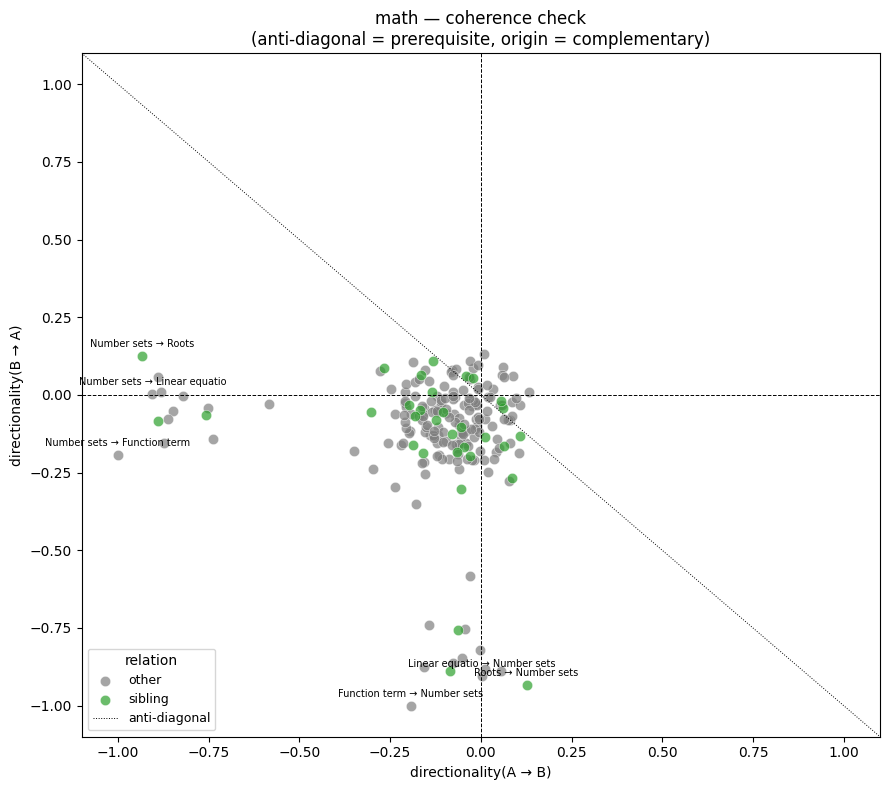

In [24]:
# Coherence scatter — math. Real prerequisite pairs sit near the anti-diagonal
# (top-left or bottom-right); complementary topics cluster at the origin.
df = outcome_with_reverse['math'].dropna(
    subset=['directionality', 'reverse_directionality']
)
fig, ax = plt.subplots(figsize=(9, 8))
for rel, grp in df.groupby('relation'):
    ax.scatter(grp['directionality'], grp['reverse_directionality'],
               color=RELATION_COLORS.get(rel, 'tab:gray'), label=rel,
               alpha=0.7, s=55, edgecolors='white', linewidths=0.4)

lim = max(df['directionality'].abs().max(),
          df['reverse_directionality'].abs().max()) * 1.1
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.axvline(0, color='black', lw=0.7, ls='--')
ax.plot([-lim, lim], [lim, -lim], color='black', lw=0.7, ls=':', label='anti-diagonal')
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

extremes = (df.assign(_r=lambda d: d['directionality']**2 +
                                    d['reverse_directionality']**2)
              .nlargest(6, '_r'))
for _, row in extremes.iterrows():
    ax.annotate(f"{row['source_name'][:14]} → {row['target_name'][:14]}",
                (row['directionality'], row['reverse_directionality']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_xlabel('directionality(A → B)')
ax.set_ylabel('directionality(B → A)')
ax.set_title('math — coherence check\n(anti-diagonal = prerequisite, origin = complementary)')
ax.legend(title='relation', fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

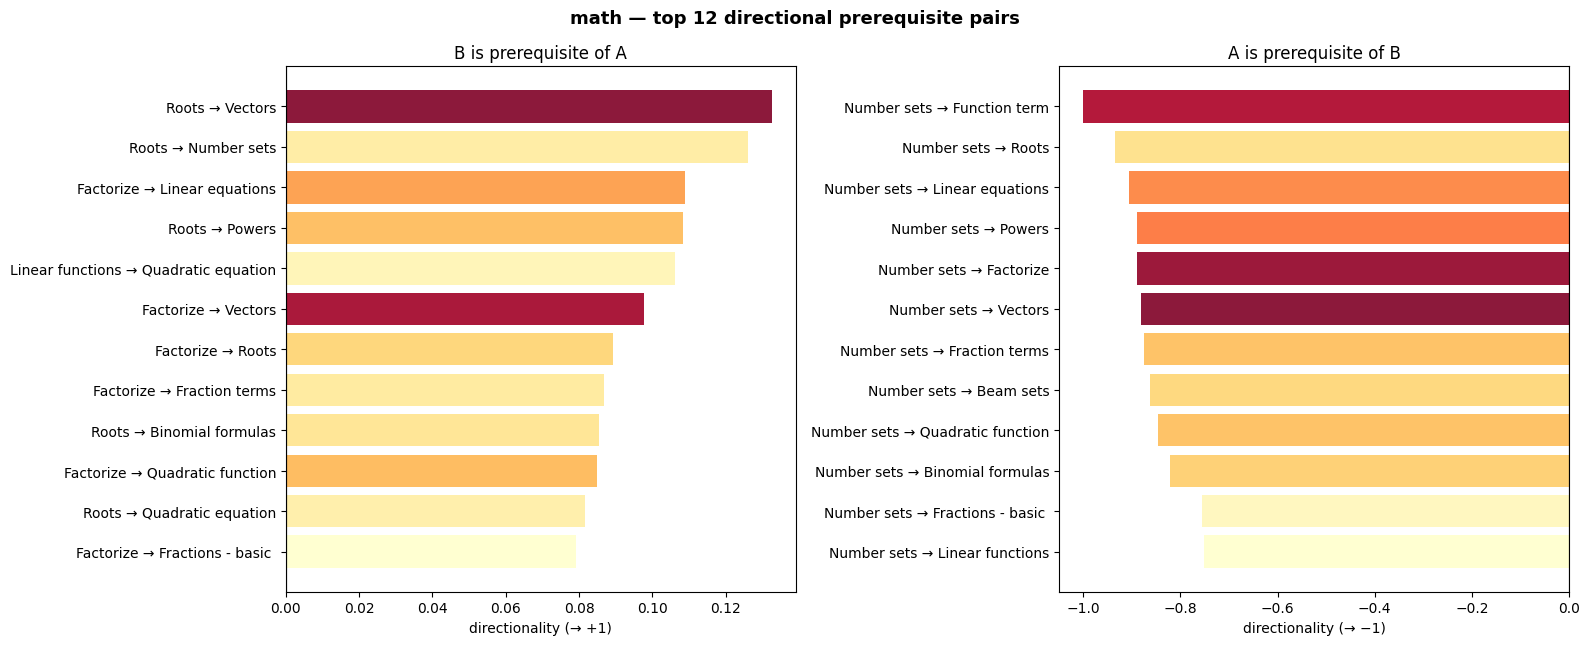

In [25]:
# Top prerequisite pairs — math. Bar color encodes relationship strength.
TOP_N = 12
df = outcome_with_reverse['math'].dropna(subset=['directionality', 'strength'])
high = df.nlargest(TOP_N,  'directionality').iloc[::-1]
low  = df.nsmallest(TOP_N, 'directionality').iloc[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 0.42 * TOP_N + 1.5))
cmap = plt.cm.YlOrRd

def _bars(ax, data, title, xlabel):
    norm = plt.Normalize(data['strength'].min(), data['strength'].max())
    labels = [f"{r['source_name'][:18]} → {r['target_name'][:18]}"
              for _, r in data.iterrows()]
    ax.barh(labels, data['directionality'],
            color=cmap(norm(data['strength'])), alpha=0.9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel(xlabel); ax.set_title(title)

_bars(ax1, high, 'B is prerequisite of A', 'directionality (→ +1)')
_bars(ax2, low,  'A is prerequisite of B', 'directionality (→ −1)')
plt.suptitle(f'math — top {TOP_N} directional prerequisite pairs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

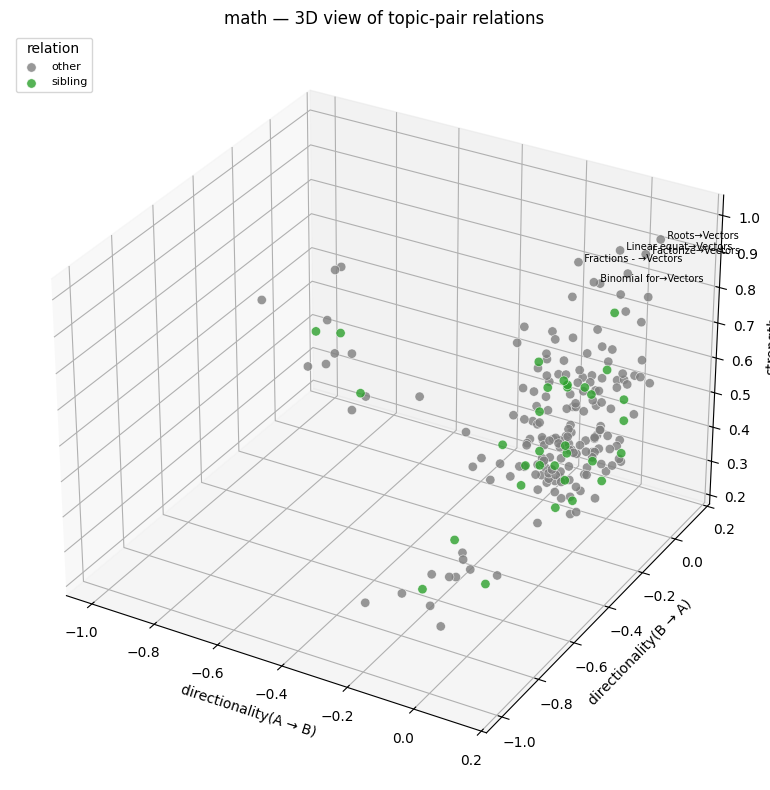

In [26]:
# 3D view — math: directionality(A→B), directionality(B→A), strength.
# Real prerequisite pairs lift along the diagonal of x and y opposite signs;
# complementary pairs sit near the (0, 0) line; strong pairs rise on z.
df = outcome_with_reverse['math'].dropna(
    subset=['directionality', 'reverse_directionality', 'strength']
)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for rel, grp in df.groupby('relation'):
    ax.scatter(grp['directionality'], grp['reverse_directionality'], grp['strength'],
               color=RELATION_COLORS.get(rel, 'tab:gray'), label=rel,
               alpha=0.8, s=45, edgecolors='white', linewidths=0.4)

# Annotate the 5 strongest pairs.
for _, row in df.nlargest(5, 'strength').iterrows():
    ax.text(row['directionality'], row['reverse_directionality'], row['strength'],
            f"  {row['source_name'][:12]}→{row['target_name'][:12]}",
            fontsize=7)

ax.set_xlabel('directionality(A → B)')
ax.set_ylabel('directionality(B → A)')
ax.set_zlabel('strength')
ax.set_title('math — 3D view of topic-pair relations')
ax.legend(title='relation', fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

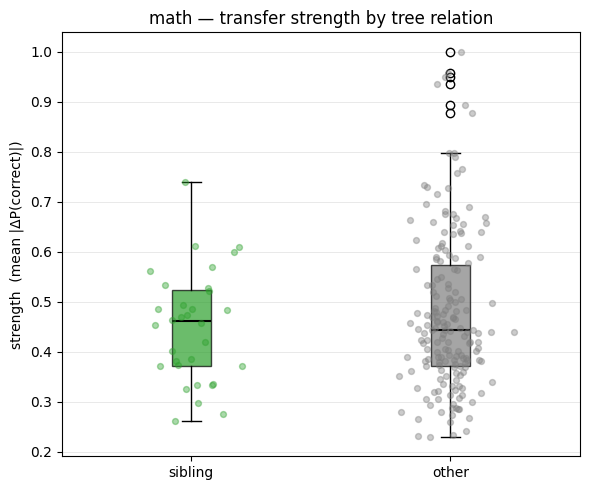

In [27]:
# Distribution of strength by relation type — math only.
fig, ax = plt.subplots(figsize=(6, 5))

df = outcome_with_reverse['math'].dropna(subset=['strength', 'relation'])
order = ['sibling', 'other']
colors = [RELATION_COLORS[r] for r in order]

data_by_rel = [df.loc[df['relation'] == r, 'strength'].values for r in order]
bp = ax.boxplot(data_by_rel, patch_artist=True, notch=False,
                medianprops=dict(color='black', lw=1.5))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)

for i, (rel, color) in enumerate(zip(order, colors), start=1):
    sub = df[df['relation'] == rel]['strength']
    ax.scatter(np.random.normal(i, 0.08, size=len(sub)), sub,
               color=color, alpha=0.4, s=18, zorder=3)

ax.set_xticks(range(1, len(order) + 1))
ax.set_xticklabels(order, fontsize=10)
ax.set_ylabel('strength  (mean |ΔP(correct)|)')
ax.set_title('math — transfer strength by tree relation')
ax.grid(axis='y', lw=0.5, alpha=0.4)

plt.tight_layout()
plt.show()


## §4. German Analysis

Same four views as §3, applied to german. The key difference to watch for is that German has a flatter topic tree and a higher share of lexical and parallel topics, so the coherence scatter is expected to show more pairs near the origin and fewer near the anti-diagonal than math.

In [28]:
# Top topic pairs by |directionality| — german.
german_top = (outcome_with_reverse['german']
              .assign(_abs=lambda d: d['directionality'].abs())
              .sort_values('_abs', ascending=False)
              .drop(columns='_abs')
              .head(20)
              .reset_index(drop=True))
german_top[['source_name', 'target_name', 'relation',
            'strength', 'directionality',
            'reverse_directionality', 'asymmetry',
            'n_obs_correct', 'n_obs_wrong']]

,source_name,target_name,relation,strength,directionality,reverse_directionality,asymmetry,n_obs_correct,n_obs_wrong
0,Spelling difficult words,Particles,other,0.593550,-1.000000,-0.075049,-0.924951,22637,1327
1,Comma for enumerations,Particles,other,0.904338,-0.769670,-0.068363,-0.701307,15960,2590
2,Spelling difficult words,Determination of the elements of the sentence,other,0.400386,-0.758819,0.015159,-0.773979,22637,1327
3,Spelling difficult words,Separation and combination,sibling,0.473026,-0.701363,-0.195898,-0.505465,22637,1327
4,Comma for enumerations,Determination of the elements of the sentence,other,0.655033,-0.631539,0.158577,-0.790115,15960,2590
5,Comma for enumerations,Pronoun,other,0.891754,-0.611936,-0.149320,-0.462616,15960,2590
6,Spelling difficult words,Pronoun,other,0.574219,-0.596283,-0.109502,-0.486781,22637,1327
7,Spelling difficult words,Noun,other,0.480265,-0.583951,0.059392,-0.643342,22637,1327
8,Spelling difficult words,Upper and lower case,sibling,0.624096,-0.561206,-0.306778,-0.254428,22637,1327
9,Comma for enumerations,Separation and combination,other,0.643831,-0.542799,-0.309500,-0.233299,15960,2590


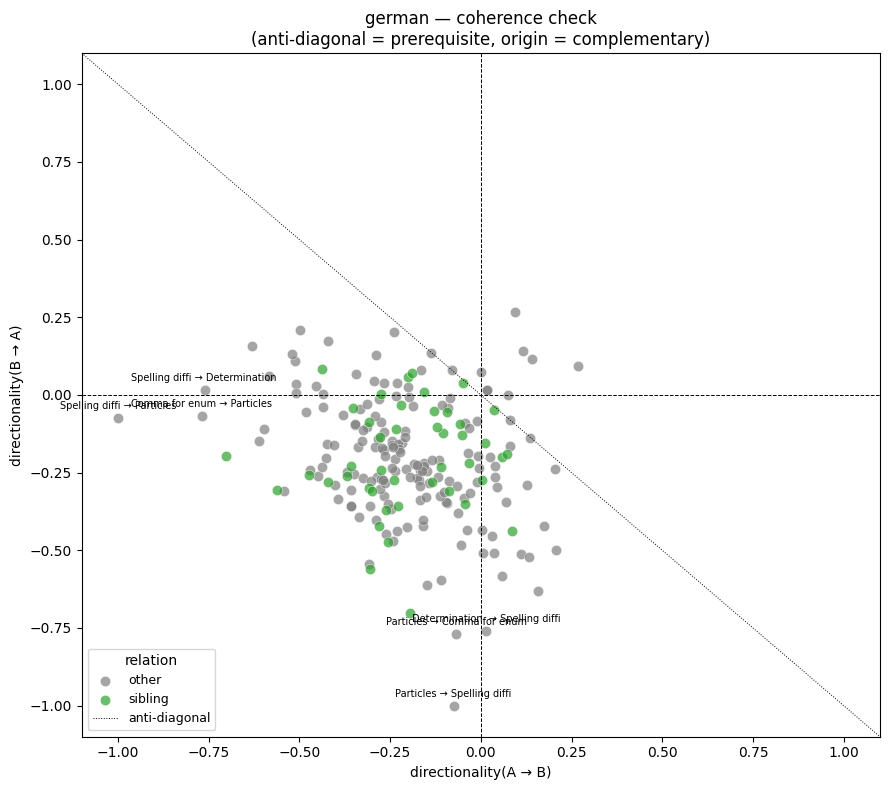

In [29]:
# Coherence scatter — german.
df = outcome_with_reverse['german'].dropna(
    subset=['directionality', 'reverse_directionality']
)
fig, ax = plt.subplots(figsize=(9, 8))
for rel, grp in df.groupby('relation'):
    ax.scatter(grp['directionality'], grp['reverse_directionality'],
               color=RELATION_COLORS.get(rel, 'tab:gray'), label=rel,
               alpha=0.7, s=55, edgecolors='white', linewidths=0.4)

lim = max(df['directionality'].abs().max(),
          df['reverse_directionality'].abs().max()) * 1.1
ax.axhline(0, color='black', lw=0.7, ls='--')
ax.axvline(0, color='black', lw=0.7, ls='--')
ax.plot([-lim, lim], [lim, -lim], color='black', lw=0.7, ls=':', label='anti-diagonal')
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)

extremes = (df.assign(_r=lambda d: d['directionality']**2 +
                                    d['reverse_directionality']**2)
              .nlargest(6, '_r'))
for _, row in extremes.iterrows():
    ax.annotate(f"{row['source_name'][:14]} → {row['target_name'][:14]}",
                (row['directionality'], row['reverse_directionality']),
                fontsize=7, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')

ax.set_xlabel('directionality(A → B)')
ax.set_ylabel('directionality(B → A)')
ax.set_title('german — coherence check\n(anti-diagonal = prerequisite, origin = complementary)')
ax.legend(title='relation', fontsize=9, loc='lower left')
plt.tight_layout()
plt.show()

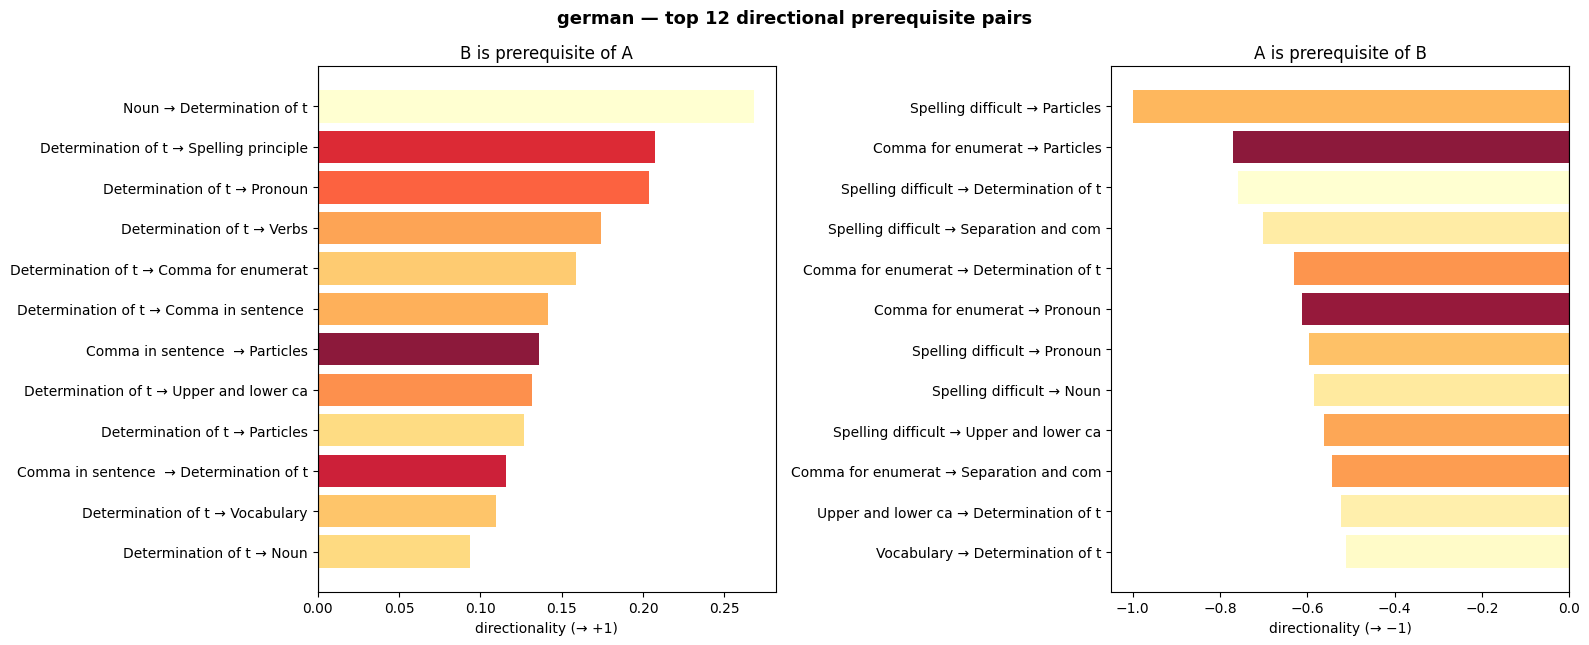

In [30]:
# Top prerequisite pairs — german. Bar color encodes relationship strength.
TOP_N = 12
df = outcome_with_reverse['german'].dropna(subset=['directionality', 'strength'])
high = df.nlargest(TOP_N,  'directionality').iloc[::-1]
low  = df.nsmallest(TOP_N, 'directionality').iloc[::-1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 0.42 * TOP_N + 1.5))
cmap = plt.cm.YlOrRd

def _bars(ax, data, title, xlabel):
    norm = plt.Normalize(data['strength'].min(), data['strength'].max())
    labels = [f"{r['source_name'][:18]} → {r['target_name'][:18]}"
              for _, r in data.iterrows()]
    ax.barh(labels, data['directionality'],
            color=cmap(norm(data['strength'])), alpha=0.9)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel(xlabel); ax.set_title(title)

_bars(ax1, high, 'B is prerequisite of A', 'directionality (→ +1)')
_bars(ax2, low,  'A is prerequisite of B', 'directionality (→ −1)')
plt.suptitle(f'german — top {TOP_N} directional prerequisite pairs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

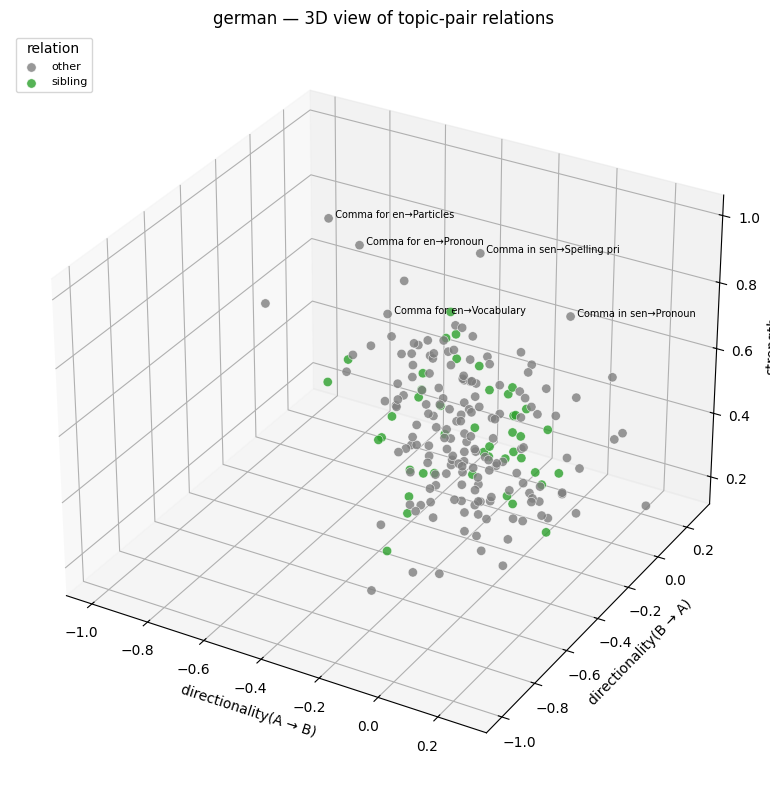

In [31]:
# 3D view — german: directionality(A→B), directionality(B→A), strength.
df = outcome_with_reverse['german'].dropna(
    subset=['directionality', 'reverse_directionality', 'strength']
)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
for rel, grp in df.groupby('relation'):
    ax.scatter(grp['directionality'], grp['reverse_directionality'], grp['strength'],
               color=RELATION_COLORS.get(rel, 'tab:gray'), label=rel,
               alpha=0.8, s=45, edgecolors='white', linewidths=0.4)

for _, row in df.nlargest(5, 'strength').iterrows():
    ax.text(row['directionality'], row['reverse_directionality'], row['strength'],
            f"  {row['source_name'][:12]}→{row['target_name'][:12]}",
            fontsize=7)

ax.set_xlabel('directionality(A → B)')
ax.set_ylabel('directionality(B → A)')
ax.set_zlabel('strength')
ax.set_title('german — 3D view of topic-pair relations')
ax.legend(title='relation', fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

## §5. Cross-subject Comparison

Aggregate statistics and distributions across both subjects. The summary table compares mean strength, mean |directionality|, and the share of pairs that fall into strong prerequisite or complementary categories. The directionality histogram and the strength-by-relation boxplots show whether the structural differences between the two subjects produce systematically different interaction patterns.

,math,german
n_pairs,210.000,210.000
mean_strength,0.473,0.449
mean_|directionality|,0.146,0.230
%_strong_B_prereq_A,0.000,0.000
%_strong_A_prereq_B,7.619,27.143
%_complementary_(|d|<0.1),54.286,24.762


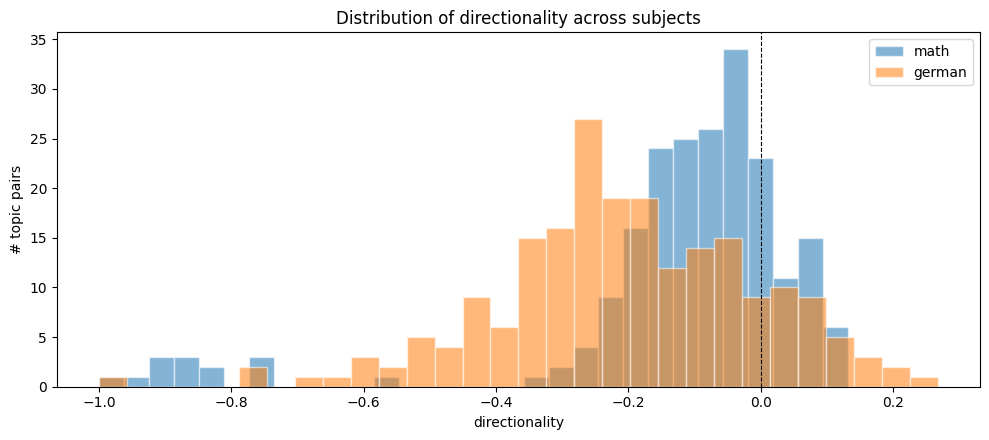

In [32]:
# Cross-subject summary: how directional are the topic-pair relations in each subject?
def _stats(df):
    df = df.dropna(subset=['directionality', 'strength'])
    return pd.Series({
        'n_pairs':                  len(df),
        'mean_strength':            df['strength'].mean(),
        'mean_|directionality|':    df['directionality'].abs().mean(),
        '%_strong_B_prereq_A':      (df['directionality'] >  0.3).mean() * 100,
        '%_strong_A_prereq_B':      (df['directionality'] < -0.3).mean() * 100,
        '%_complementary_(|d|<0.1)': (df['directionality'].abs() < 0.1).mean() * 100,
    })

summary = pd.DataFrame({s: _stats(outcome_with_reverse[s]) for s in SUBJECTS}).round(3)
display(summary)

# Side-by-side directionality distribution.
fig, ax = plt.subplots(figsize=(10, 4.5))
for subject, color in zip(SUBJECTS, ['tab:blue', 'tab:orange']):
    df = outcome_with_reverse[subject].dropna(subset=['directionality'])
    ax.hist(df['directionality'], bins=30, alpha=0.55, label=subject,
            color=color, edgecolor='white')
ax.axvline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('directionality'); ax.set_ylabel('# topic pairs')
ax.set_title('Distribution of directionality across subjects')
ax.legend()
plt.tight_layout()
plt.show()

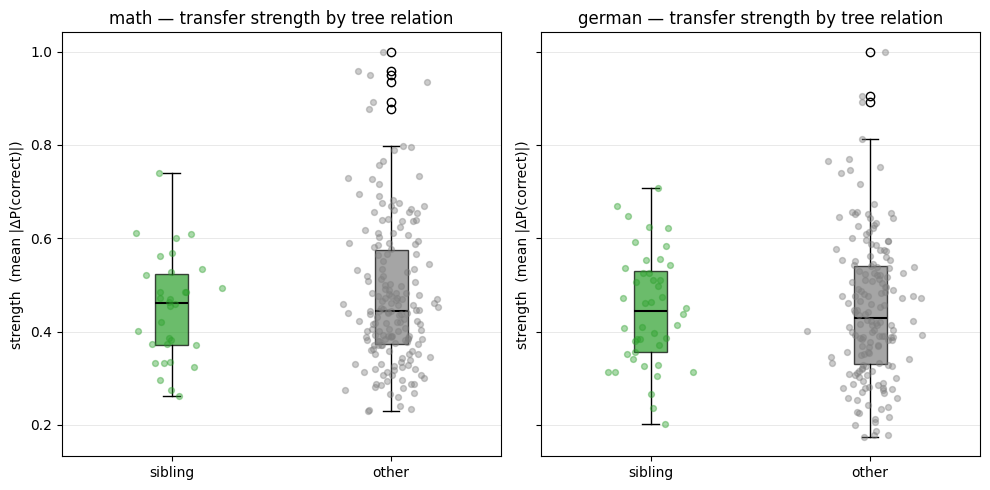

In [33]:
# Distribution of strength by relation type — both subjects side by side.
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

for ax, subject in zip(axes, SUBJECTS):
    df = outcome_with_reverse[subject].dropna(subset=['strength', 'relation'])
    order = ['sibling', 'other']
    colors = [RELATION_COLORS[r] for r in order]

    data_by_rel = [df.loc[df['relation'] == r, 'strength'].values for r in order]
    bp = ax.boxplot(data_by_rel, patch_artist=True, notch=False,
                    medianprops=dict(color='black', lw=1.5))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)

    for i, (rel, color) in enumerate(zip(order, colors), start=1):
        sub = df[df['relation'] == rel]['strength']
        ax.scatter(np.random.normal(i, 0.08, size=len(sub)), sub,
                   color=color, alpha=0.4, s=18, zorder=3)

    ax.set_xticks(range(1, len(order) + 1))
    ax.set_xticklabels(order, fontsize=10)
    ax.set_ylabel('strength  (mean |ΔP(correct)|)')
    ax.set_title(f'{subject} — transfer strength by tree relation')
    ax.grid(axis='y', lw=0.5, alpha=0.4)

plt.tight_layout()
plt.show()

## §6. Prerequisite Score

`directionality` is a directed metric: directionality(A→B) and directionality(B→A) are two separate numbers for the same pair of topics. To decide which of A or B is the prerequisite, we need a single signed scalar per unordered pair that captures the net asymmetry between the two directions. That is what the prerequisite score provides.

The prerequisite score collapses both directed signals into one number per unordered pair:

$$\text{prerequisite\_score}(A,B) \;=\; \frac{\text{directionality}(B \to A) \;-\; \text{directionality}(A \to B)}{2}$$

| Value | Meaning |
|-------|---------|
| **+1** | A is a strong prerequisite of B |
| **-1** | B is a strong prerequisite of A |
| **0** | complementary / symmetric |

By construction: score(A,B) = -score(B,A) and score(A,A) = 0.


=== MATH — top 15 by |prerequisite score| ===


,source_name,target_name,relation,prerequisite_score,strength
0,Number sets,Roots,sibling,0.530265,0.420145
1,Roots,Number sets,sibling,-0.530265,0.484304
2,Number sets,Factorize,other,0.472739,0.656469
3,Factorize,Number sets,other,-0.472739,0.481520
4,Number sets,Linear equations,other,0.454239,0.519337
5,Linear equations,Number sets,other,-0.454239,0.453578
6,Vectors,Number sets,other,-0.446110,0.443545
7,Number sets,Vectors,other,0.446110,0.668672
8,Number sets,Binomial formulas,other,0.409063,0.444316
9,Binomial formulas,Number sets,other,-0.409063,0.457973



=== GERMAN — top 15 by |prerequisite score| ===


,source_name,target_name,relation,prerequisite_score,strength
0,Particles,Spelling difficult words,other,-0.462476,0.369606
1,Spelling difficult words,Particles,other,0.462476,0.593550
2,Comma for enumerations,Determination of the elements of the sentence,other,0.395058,0.655033
3,Determination of the elements of the sentence,Comma for enumerations,other,-0.395058,0.331973
4,Spelling difficult words,Determination of the elements of the sentence,other,0.386989,0.400386
5,Determination of the elements of the sentence,Spelling difficult words,other,-0.386989,0.328871
6,Determination of the elements of the sentence,Spelling principles,other,-0.353278,0.521496
7,Spelling principles,Determination of the elements of the sentence,other,0.353278,0.445513
8,Particles,Comma for enumerations,other,-0.350653,0.315137
9,Comma for enumerations,Particles,other,0.350653,0.904338



=== Antisymmetry check (max |score(A,B) + score(B,A)|, should be ~0) ===
  math: max error = 0.00e+00
  german: max error = 0.00e+00


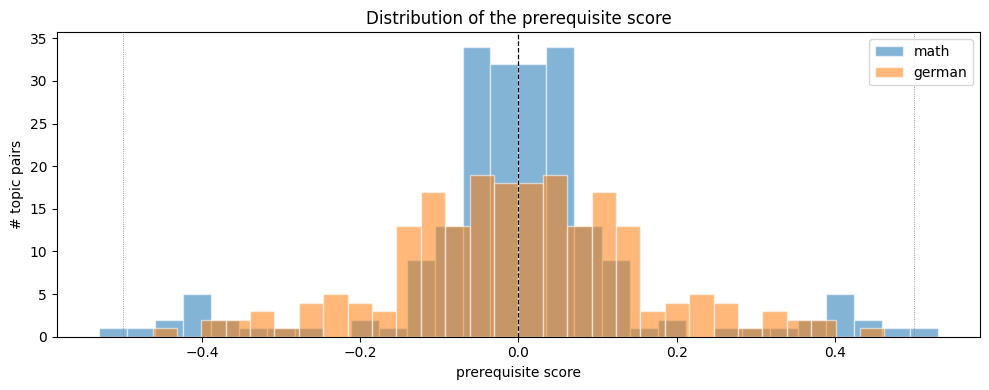

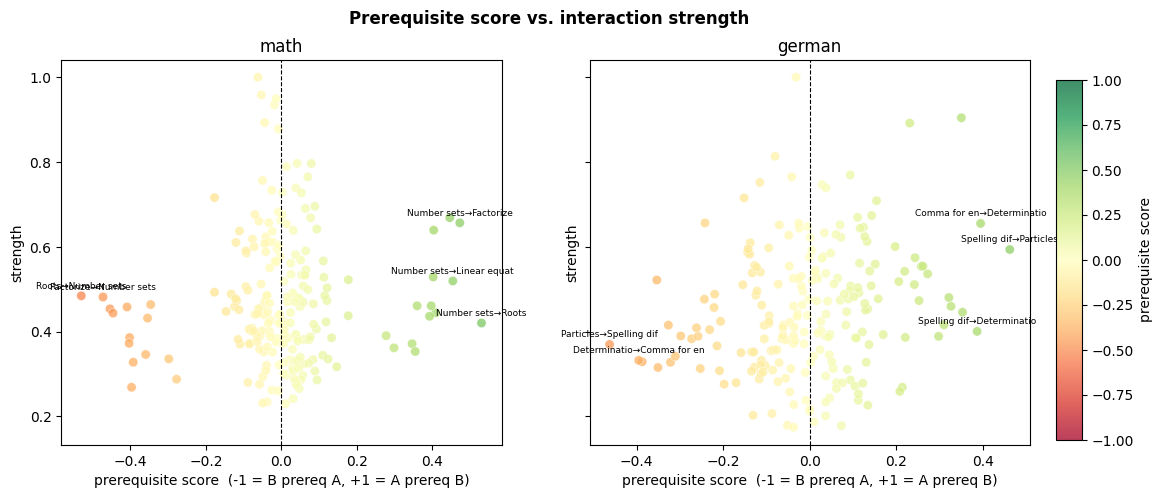

In [34]:
from src.post_analysis import prerequisite_score

prereq = {s: prerequisite_score(outcome_with_reverse[s]) for s in SUBJECTS}

# ── Top pairs by prerequisite score ───────────────────────────────────────
TOP_N = 15
for subject in SUBJECTS:
    df = prereq[subject].dropna(subset=['prerequisite_score'])
    top = (df.assign(_abs=df['prerequisite_score'].abs())
             .sort_values('_abs', ascending=False)
             .drop(columns='_abs')
             .head(TOP_N)
             .reset_index(drop=True))
    print(f"\n=== {subject.upper()} — top {TOP_N} by |prerequisite score| ===")
    display(top[['source_name', 'target_name', 'relation',
                 'prerequisite_score', 'strength']])

# ── Antisymmetry sanity check ─────────────────────────────────────────────
# For every (A,B) row find (B,A) and verify score(A,B) ≈ -score(B,A).
print("\n=== Antisymmetry check (max |score(A,B) + score(B,A)|, should be ~0) ===")
for subject in SUBJECTS:
    df = prereq[subject][['source_topic', 'target_topic', 'prerequisite_score']].dropna()
    reverse = df.rename(columns={'source_topic': 'target_topic',
                                 'target_topic': 'source_topic',
                                 'prerequisite_score': 'score_reverse'})
    merged = df.merge(reverse, on=['source_topic', 'target_topic'])
    err = (merged['prerequisite_score'] + merged['score_reverse']).abs().max()
    print(f"  {subject}: max error = {err:.2e}")

# ── Distribution of prerequisite score ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
for subject, color in zip(SUBJECTS, ['tab:blue', 'tab:orange']):
    df = prereq[subject].dropna(subset=['prerequisite_score'])
    ax.hist(df['prerequisite_score'], bins=30, alpha=0.55, label=subject,
            color=color, edgecolor='white')
ax.axvline(0, color='black', lw=0.9, ls='--')
ax.axvline( 0.5, color='gray', lw=0.6, ls=':')
ax.axvline(-0.5, color='gray', lw=0.6, ls=':')
ax.set_xlabel('prerequisite score')
ax.set_ylabel('# topic pairs')
ax.set_title('Distribution of the prerequisite score')
ax.legend()
plt.tight_layout()
plt.show()

# ── Scatter: prerequisite score vs strength ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, subject in zip(axes, SUBJECTS):
    df = prereq[subject].dropna(subset=['prerequisite_score', 'strength'])
    sc = ax.scatter(df['prerequisite_score'], df['strength'],
                    c=df['prerequisite_score'], cmap='RdYlGn',
                    vmin=-1, vmax=1, alpha=0.75, s=45,
                    edgecolors='white', linewidths=0.4)
    for _, row in df.assign(_abs=df['prerequisite_score'].abs()).nlargest(5, '_abs').iterrows():
        ax.annotate(f"{row['source_name'][:12]}→{row['target_name'][:12]}",
                    (row['prerequisite_score'], row['strength']),
                    fontsize=6.5, ha='center', va='bottom',
                    xytext=(0, 4), textcoords='offset points')
    ax.axvline(0, color='black', lw=0.8, ls='--')
    ax.set_xlabel('prerequisite score  (-1 = B prereq A, +1 = A prereq B)')
    ax.set_ylabel('strength')
    ax.set_title(f'{subject}')
plt.suptitle('Prerequisite score vs. interaction strength', fontsize=12, fontweight='bold')
fig.subplots_adjust(right=0.87, top=0.88)
cbar_ax = fig.add_axes([0.89, 0.12, 0.02, 0.72])
fig.colorbar(sc, cax=cbar_ax, label='prerequisite score')
plt.show()

### Interpretation

**Distribution of prerequisite score.**
Math shows a distribution concentrated near the extremes: fewer topic pairs carry a strong prerequisite signal, but those that do are highly directional. This is consistent with a subject built around a small number of foundational concepts with clear ordering. German's distribution is broader and more centred, with many pairs carrying a weak but non-zero score spread across the full range. More prerequisite relationships exist in German, but they are less decisive: the curriculum is less strictly ordered.

**Prerequisite score vs. strength.**
The scatter reveals an important asymmetry: the highest-strength interactions (the most reliably detected relationships) cluster near a prerequisite score of zero rather than at the extremes. This means the strongest signals in the data come from topics that are highly correlated in both directions, not from strict prerequisite pairs. Topics that should be learned together produce the clearest and most consistent effect on the model's probability estimates. Strongly directional pairs do exist, but they carry lower overall strength, making them less certain signals even when the direction is clear.

## §7. Curriculum Graphs

A directed acyclic graph (DAG) per subject where an edge A → B means **"A is a prerequisite of B"**.

1. Keep only edges where the prerequisite score > 0: direction is given, A is a prerequisite of B
2. **Strength floor**: drop edges below the `STRENGTH_PERCENTILE` of strength (reliability gate)
3. **Score quality cutoff**: keep the top `(100 - F_PERCENTILE)%` by prerequisite score among survivors
4. Sort by prerequisite score descending; add each edge greedily, **skipping any edge that would create a cycle**
5. Exhaust the filtered list; isolated topics are valid output (no strong signal found)

**Why greedy cycle avoidance rather than a simple threshold cut?**
After applying the strength and score filters, the remaining edges may still contain cycles: pairs where A appears to be a prerequisite of B and B appears to be a prerequisite of A simultaneously. These cycles reflect conflicting or symmetric signals in the data, not genuine circular dependencies in the curriculum. Rather than discarding all edges involved in a cycle, the greedy approach keeps the strongest edges and skips only those that would close a cycle, preserving as much of the DAG structure as the data supports.

Thresholds are computed **per subject** so math and german are calibrated independently.


=== MATH ===
  Nodes: 7  |  Edges: 7  |  Isolated: 0


,source_name,target_name,prerequisite_score,strength,relation
0,Number sets,Factorize,0.473,0.6565,other
1,Number sets,Vectors,0.446,0.6687,other
2,Number sets,Function term,0.404,0.6392,other
3,Function term,Factorize,0.111,0.5666,other
4,Powers,Factorize,0.094,0.6419,other
5,Fraction terms,Vectors,0.089,0.6954,other
6,Fractions - basic arithmetic operations,Factorize,0.079,0.7965,other



=== GERMAN ===
  Nodes: 7  |  Edges: 7  |  Isolated: 0


,source_name,target_name,prerequisite_score,strength,relation
0,Spelling difficult words,Particles,0.462,0.5936,other
1,Comma for enumerations,Determination of the elements of the sentence,0.395,0.6550,other
2,Comma for enumerations,Particles,0.351,0.9043,other
3,Spelling difficult words,Pronoun,0.243,0.5742,other
4,Comma for enumerations,Pronoun,0.231,0.8918,other
5,Comma for enumerations,Noun,0.198,0.6004,other
6,Comma for enumerations,Comma in sentence structure,0.155,0.7087,sibling


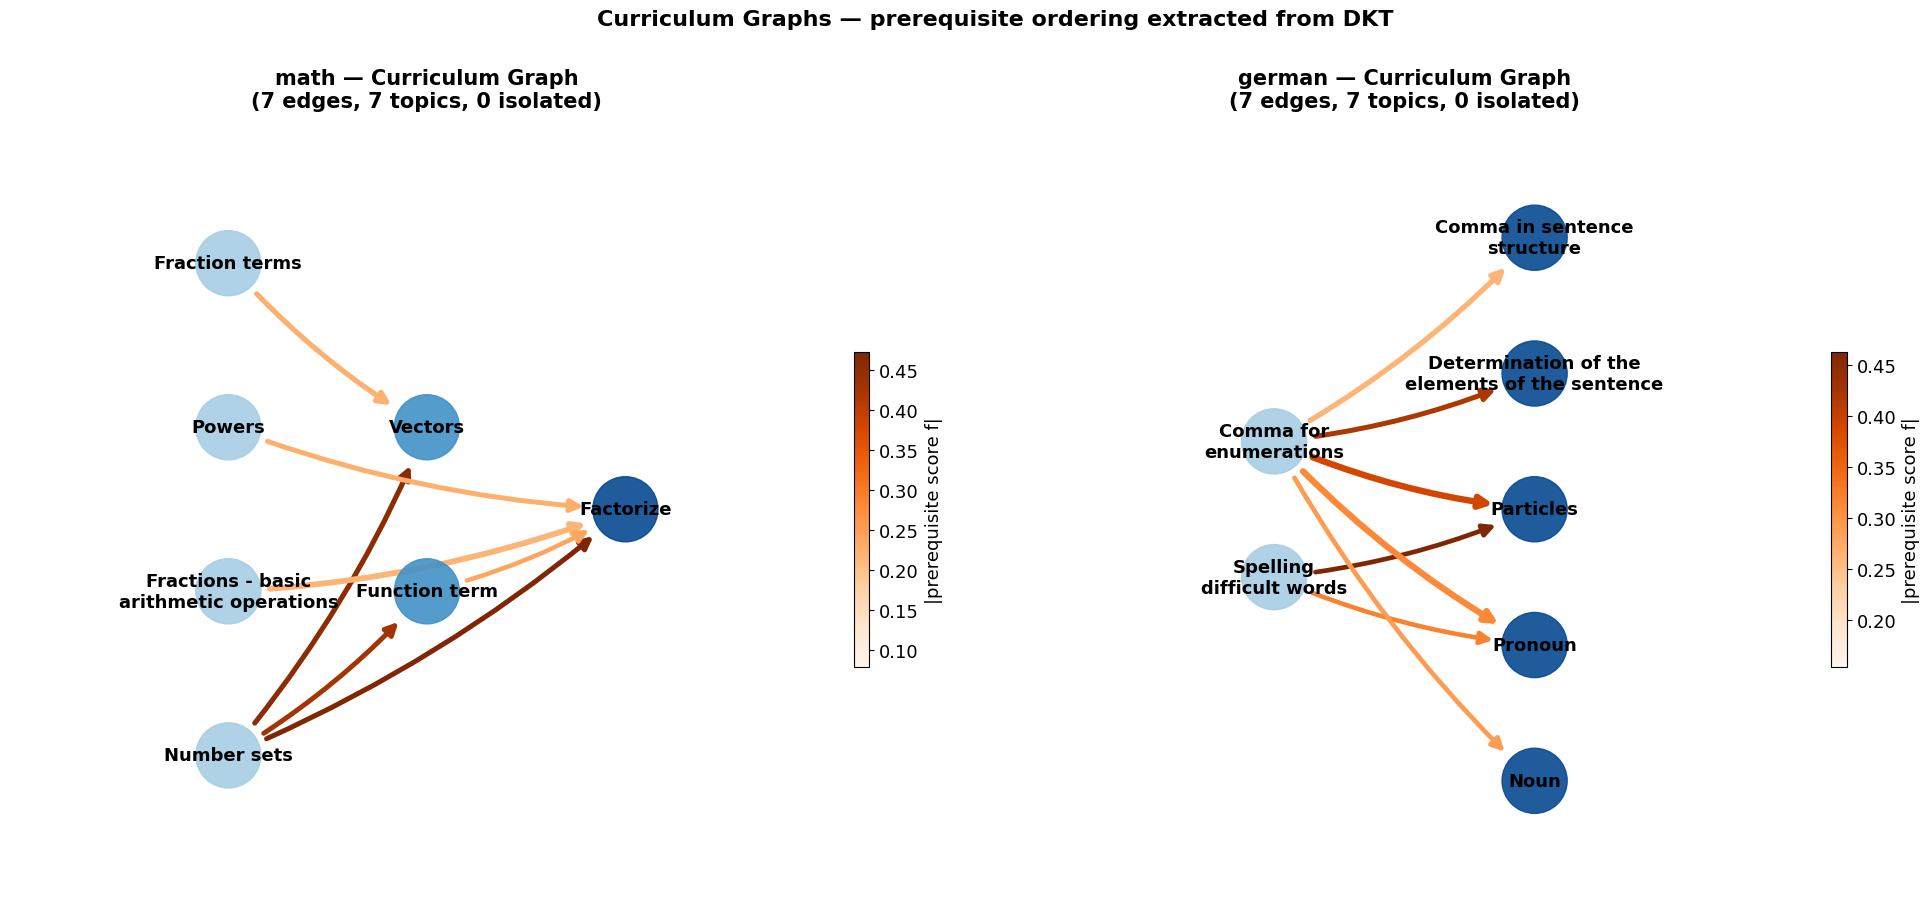


=== Topological study order ===

  math: Fraction terms → Number sets → Fractions - basic arithmetic operations → Powers → Vectors → Function term → Factorize

  german: Spelling difficult words → Comma for enumerations → Determination of the elements of the sentence → Particles → Pronoun → Noun → Comma in sentence structure


In [35]:
# ── Thresholds (per-subject percentiles) ────────────────────────────────────
STRENGTH_PERCENTILE = 75   # reliability floor: keep edges above this strength percentile
F_PERCENTILE        = 75   # quality cutoff:    keep top 50% by f among survivors

GRAPH_FONT_SIZE     = 13    # font size for all text in the curriculum graphs

# ── Build one curriculum graph per subject ───────────────────────────────────
curriculum_edges, curriculum_graphs = {}, {}

for subject in SUBJECTS:
    edges_df, G = build_curriculum_graph(
        prereq[subject],
        strength_percentile=STRENGTH_PERCENTILE,
        f_percentile=F_PERCENTILE,
    )
    curriculum_edges[subject]  = edges_df
    curriculum_graphs[subject] = G

    import networkx as nx
    isolated   = list(nx.isolates(G))
    n_iso_names = [G.nodes[n].get('name', str(n)) for n in isolated]
    print(f"\n=== {subject.upper()} ===")
    print(f"  Nodes: {G.number_of_nodes()}  |  Edges: {G.number_of_edges()}  "
          f"|  Isolated: {len(isolated)}")
    if n_iso_names:
        print(f"  Isolated topics: {', '.join(n_iso_names)}")
    display(edges_df[['source_name', 'target_name',
                       'prerequisite_score', 'strength', 'relation']]
            .style.format({'prerequisite_score': '{:.3f}', 'strength': '{:.4f}'}))

# ── Visualise both graphs side by side ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
for ax, subject in zip(axes, SUBJECTS):
    plot_curriculum_graph(curriculum_graphs[subject], subject=subject, ax=ax,
                          font_size=GRAPH_FONT_SIZE)
plt.suptitle('Curriculum Graphs — prerequisite ordering extracted from DKT',
             fontsize=GRAPH_FONT_SIZE + 3, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ── Topological ordering (one valid study sequence per subject) ──────────────
print("\n=== Topological study order ===")
for subject in SUBJECTS:
    G = curriculum_graphs[subject]
    try:
        order = list(nx.topological_sort(G))
        names = [G.nodes[n].get('name', str(n)) for n in order]
        print(f"\n  {subject}: {' → '.join(names)}")
    except nx.NetworkXUnfeasible:
        print(f"\n  {subject}: cycle detected — graph is not a DAG (bug)")

## §8. Skill-Level Curriculum Graph

Extends §7 to the **skill** level (topic × difficulty band). Edges now capture cross-topic prerequisite relationships at a specific difficulty, e.g. "Fractions d=2 is a prerequisite of Division d=3".

### Methodology (same as §7, applied at skill granularity)

1. **Qualifying skills**: restricted to the top-15 topics, ≥ `MIN_SKILL_ATTEMPTS` attempts, and `difficulty ≠ EXCLUDE_DIFFICULTY` (sentinel for missing values).
2. **Skill-level interactions**: compute strength and directionality directly on (source_skill, target_skill) pairs without aggregating across difficulty bands.
3. **Prerequisite score**: same antisymmetric formula as §6.
4. **Greedy acyclic DAG**: same algorithm as §7 (strength floor, score cutoff, cycle check).

### Visualisation

An **interactive HTML graph** (vis.js, loaded from CDN) per subject. Layout:
- **x-axis** = topic curriculum order from §7 (early prerequisites left)
- **y-axis** = difficulty band (d=1 bottom, d=4 top)
- **node colour** = topic (same-topic skills share a colour)
- **click a node** highlights its full prerequisite chain (ancestors in blue, descendants in green); click again or the background to reset.

In [ ]:
import pathlib
import networkx as nx
from IPython.display import IFrame, display as ipy_display

# ── Thresholds (per-subject percentiles) ────────────────────────────────────
# Same semantics as §7 — adjust to control graph density.
SKILL_STRENGTH_PERCENTILE = 50   # reliability floor for skill-level edges
SKILL_F_PERCENTILE        = 50   # f quality cutoff among survivors

# ── Qualifying skill filter ──────────────────────────────────────────────────
MIN_SKILL_ATTEMPTS = 1000   # discard skills answered fewer times than this
EXCLUDE_DIFFICULTY = -2     # sentinel value for missing estimatedDifficulty

RAPPORT_DIR = pathlib.Path('rapport')
RAPPORT_DIR.mkdir(exist_ok=True)

# ── Build skill-level interactions and curriculum graphs ─────────────────────
skill_outcome = {}
skill_prereq  = {}
skill_edges   = {}
skill_graphs  = {}

for subject in SUBJECTS:
    arr = delta_arrays[subject]

    # Skill-level interactions (correct vs wrong outcome) — no topic aggregation.
    skill_outcome[subject] = skill_skill_interactions_by_outcome(
        arr['wide_pc'], arr['delta_all'],
        arr['src_skill'], arr['src_correct'],
        skill_info[subject], focus_topic_ids[subject],
        lookups['child_to_parent'],
        min_attempts=MIN_SKILL_ATTEMPTS,
        exclude_difficulty=EXCLUDE_DIFFICULTY,
        before_all=arr['before_all'],
        mode=DELTA_MODE,
        balance_by_outcome_ratio=BALANCE_BY_OUTCOME_RATIO,
    )

    # Antisymmetric prerequisite score (same formula as §6).
    skill_prereq[subject] = prerequisite_score(skill_outcome[subject])

    # Greedy acyclic DAG (same algorithm as §7, applied at skill level).
    edges_df, G = build_skill_curriculum_graph(
        skill_prereq[subject],
        skill_info[subject],
        strength_percentile=SKILL_STRENGTH_PERCENTILE,
        f_percentile=SKILL_F_PERCENTILE,
    )
    skill_edges[subject]  = edges_df
    skill_graphs[subject] = G

    isolated = list(nx.isolates(G))
    print(f"\n=== {subject.upper()} ===")
    print(f"  Qualifying skills: {skill_outcome[subject]['source_skill'].nunique()}"
          f"  |  Nodes: {G.number_of_nodes()}"
          f"  |  Edges: {G.number_of_edges()}"
          f"  |  Isolated: {len(isolated)}")
    display(
        edges_df[['source_name', 'source_diff', 'target_name', 'target_diff',
                  'prerequisite_score', 'strength', 'relation']]
        .head(5)
        .style.format({'prerequisite_score': '{:.3f}', 'strength': '{:.4f}'})
    )

# ── Topic ordering for the grouped layout: reuse §7 topological sort ─────────
topic_order = {}
for subject in SUBJECTS:
    G7    = curriculum_graphs[subject]
    order = list(nx.topological_sort(G7))
    # Append any focus topics that are isolated in §7 (no strong topic-level signal).
    remaining = [t for t in sorted(focus_topic_ids[subject]) if t not in order]
    order += remaining
    topic_order[subject] = {tid: i for i, tid in enumerate(order)}

# ── Generate interactive HTML graphs (vis.js, no extra dependencies) ─────────
for subject in SUBJECTS:
    html_path = plot_skill_curriculum_html(
        skill_graphs[subject],
        subject=subject,
        topic_order=topic_order[subject],
        output_path=RAPPORT_DIR / f'skill_curriculum_{subject}.html',
        # Adjust spacing if the graph looks cramped or too spread out:
        x_spacing=220,
        y_spacing=130,
    )
    print(f"\n{subject}: interactive graph saved → {html_path}")



=== MATH ===
  Qualifying skills: 43  |  Nodes: 42  |  Edges: 225  |  Isolated: 0


/Users/christophe/MLBD-project/src/post_analysis.py:861: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_l = g.mean().stack(dropna=False).rename(f'mean_abs_delta_{suffix}')
/Users/christophe/MLBD-project/src/post_analysis.py:861: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_l = g.mean().stack(dropna=False).rename(f'mean_abs_delta_{suffix}')


,source_name,source_diff,target_name,target_diff,prerequisite_score,strength,relation
0,Number sets,2,Number sets,3,0.785,0.2694,same-topic
1,Number sets,1,Roots,1,0.554,0.6905,sibling
2,Number sets,2,Powers,1,0.495,0.3432,sibling
3,Number sets,1,Factorize,1,0.486,0.4294,other
4,Number sets,2,Vectors,2,0.483,0.4608,other



=== GERMAN ===
  Qualifying skills: 57  |  Nodes: 56  |  Edges: 374  |  Isolated: 0


/Users/christophe/MLBD-project/src/post_analysis.py:861: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_l = g.mean().stack(dropna=False).rename(f'mean_abs_delta_{suffix}')
/Users/christophe/MLBD-project/src/post_analysis.py:861: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  mean_l = g.mean().stack(dropna=False).rename(f'mean_abs_delta_{suffix}')


,source_name,source_diff,target_name,target_diff,prerequisite_score,strength,relation
0,Upper and lower case,3,Particles,2,1.092,0.2420,other
1,Upper and lower case,3,Particles,3,0.858,0.2992,other
2,Comma for enumerations,3,Comma for additions,3,0.813,0.2259,sibling
3,Verbs,3,Comma for enumerations,3,0.773,0.2678,other
4,Spelling difficult words,1,Determination of the elements of the sentence,2,0.732,0.3985,other



math: interactive graph saved → rapport/skill_curriculum_math.html

german: interactive graph saved → rapport/skill_curriculum_german.html


## Conclusion

### Main Takeaways

The DKT model produces probability estimates that improve on the majority-class baseline by around 0.24 AUC on both subjects, which suggests that interaction sequences carry information about student knowledge state beyond simple class frequencies.

The two subjects behave differently. Math has a small number of strongly directional topic pairs, consistent with a subject that has a relatively clear hierarchical structure. German has more topic pairs with weaker individual signals and a prerequisite score distribution that is more spread out, which fits a domain where many topics are parallel rather than ordered.

One pattern stands out across both subjects: the highest-strength interactions tend to cluster near a prerequisite score of zero. The strongest signals in the data come from topics that are correlated in both directions rather than from strict prerequisite pairs. These topics are better described as co-occurring content that benefits from being practiced together, rather than content with a clear ordering.

### Recommendations

For math, the curriculum graph identifies a small number of topics (Number sets, Fraction terms, Function term) that show strong directional relationships with many other topics. These could be used to inform study path design: if a student struggles with a downstream topic, checking whether the identified prerequisites have been covered first is a reasonable starting point.

For German, the weaker ordering signal suggests that grouping related topics together in a session is more appropriate than enforcing a strict sequence. The co-occurrence structure identified here could inform how topic bundles are assembled on the platform.

The skill-level graph adds granularity by operating at the topic x difficulty level rather than topic alone. Rather than recommending a topic in general, it points to specific topic-difficulty combinations, which may give more actionable remediation targets.

The interactive graphs saved in `rapport/` could be reviewed together with the startup's pedagogical team to check whether the data-driven orderings match their existing curriculum design and flag any disagreements worth investigating.

### Further Work

The analysis is restricted to the 15 most-attempted topics per subject. Extending it to all topics would give a more complete picture but requires either more compute or changes to how the delta matrix is constructed to keep it tractable.

The graphs produced here are population-level averages. Students with unusual practice histories may show different prerequisite patterns. Using per-student DKT predictions to build individual-level graphs would be a more personalised version of the same approach, though it would require considerably more data per student to be reliable.

The most direct way to evaluate whether the identified prerequisite ordering is useful in practice would be a prospective study: present one group of students with content following the recommended sequence and compare their learning outcomes against a group using the current platform ordering.

Finally, the model architecture could be revisited. Transformer-based knowledge tracing models have shown better performance on longer sequences than LSTMs in the literature, which could sharpen the prerequisite signal, particularly for German where the current signals are weaker.